# Exercise 8 - Cats, Cats, and EigenCats 

Are you sad that you have watched all cat movies and seen all cat photos on the internet? Then be sad no more - in this exercise we will make a *Cat Synthesizer* where you can create all the cat photos you will ever need!

Secondly, a very unfortunate event happened so you are now in a situation, where you need to find a *perfect new twin cat*.
 
To be able to do these wonderful things we will harness the power of image based *principal component analysis*. The methods we will use, can be called *classical machine learning*.

![Missing Cat](figures/MissingCatProcessed.jpg)

## Learning Objectives

After completing this exercise, the student should be able to do the following:

1. Preprocess a batch of images so they can be used to machine learning. Preprocessing can include geometric transformations, intensity transformations and image cropping. 
2. Use the python function `glob` to find all files with a given pattern in a folder.
3. Create an empty data matrix that can hold a given set of images and a given number of measurements per image.
4. Compute the number of features per image using the height, width and the number of channels in the image.
5. Use the function `flatten` to convert an image into a 1-D vector.
6. Create an image from a 1-D vector by using the [`reshape`](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html) function.
7. Create an unsigned byte image from a float image using pixel value scaling and pixel type conversion.
8. Read a set of images and put their pixel values into a data matrix.
9. Compute an average image using the data matrix.
10. Visualize an average image
11. Preprocess one image so it can be used in machine learning.
12. Use sum-of-squared pixel differences (SSD) to compare one image with all images in a training set.
13. Identify and visualize the images in the training set with the smallest and largest SSD compared to a given image.
14. Do a principal component analysis (PCA) of the data matrix using the [sci-kit learn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
15. Select the number of components that should be computed in the PCA.
16. Extract and visualize the amount of the total variation that each principal component explains. 
17. Project the data matrix into PCA space.
18. Plot the first two dimensions of the PCA space. The PCA space is the positions of each sample when projected onto the principal components.
19. Identify and visualize the images that have extreme positions in PCA. For example the images that have the largest and smallest coordinates in PCA space.
20. Compute and visualize a synthetic image by adding linear combinations of principal components to the average image.
21. Select suitable weights based on the PCA space for synthesizing images.
22. Compute and visualize the major modes of variation in the training set, by sampling along the principal components.
23. Generate random synthetic images that lies within the PCA space of the training set.
24. Project a given image into PCA space
25. Generate a synthetich version of an image by using the image position in PCA space.
26. Compute the Euclidean distance in PCA space between a given image and all other images.
27. Identify and visualize the images in the training set with the smallest and largest Euclidean distance in PCA space to a given image.
28. Use [`argpartition`](https://numpy.org/doc/stable/reference/generated/numpy.argpartition.html) to find the N closest images in PCA space to a given image.

## Importing required Python packages

We will use the virtual environment from the previous exercise (`course02503`). 

Let us start with some imports:

In [2]:
from skimage import io
from skimage.util import img_as_ubyte
import matplotlib.pyplot as plt
import numpy as np
import glob
from sklearn.decomposition import PCA
from skimage.transform import SimilarityTransform
from skimage.transform import warp
import os
import pathlib

## Exercise data and material

The data and material needed for this exercise can be found here: 
[exercise data and material](https://github.com/RasmusRPaulsen/DTUImageAnalysis/tree/main/exercises/ex8-CatsCatsCats/data)

The main part of the data is a large database of photos of cats, where there are also a set of landmarks per photo. You should download the data [here](https://courses.compute.dtu.dk/02502/data/training_cats.zip). 

**IMPORTANT:** You can start by working with the smaller data set with 100 cats found here: [smaller photo database of 100 cats](https://courses.compute.dtu.dk/02502/data/training_cats_100.zip). Later you can use the full data set and see if your computer has enough RAM to handle it.

Start by unpacking all the training photos in folder you choose. For example `training_data`. 

## Preprocessing data for machine learning

The photos contains cats in many situations and backgrounds. To make it easier to do machine learning, we will *preprocess* the data, so the photos only contains the face of the cat. Preprocessing is and important step in most machine learning approaches.

The preprocessing steps are:

- Define a model cat (`ModelCat.jpg`) with associated landmarks (`ModelCat.jpg.cat`)
- For each cat in the training data:
  - Use landmark based registration with a *similarity transform* to register the photo to the model cat
  - Crop the registered photo
  - Save the result in a fold called **preprocessed**

**Exercise 1:** *Preprocess all image in the training set. To do the preprocessing, you can use the code snippets supplied* [here](https://github.com/RasmusRPaulsen/DTUImageAnalysis/tree/main/exercises/ex8-CatsCatsCats/data). There is also a **Model Cat** supplied.


In [3]:
#preprocess.py


The result of the preprocessing is a directory containing smaller photos containing cat faces. All the preprocessed photos also have the same size. 

## Gathering data into a data matrix

To start, we want to collect all the image data into a data matrix. The matrix should have dimensions `[n_samples, n_features]` where **n_samples** is the number of photos in our training set and **n_features** is the number of values per image. Since we are working with RGB images, the number of features are given by `n_features = height * width * channels`, where `channels = 3`. 

The data matrix can be constructed by:

- Find the number of image files in the **preprocessed** folder using [`glob`](https://docs.python.org/3/library/glob.html). Look at the `preprocess_all_cats` function to get an idea of how to use `glob`. 
- Read the first photo and use that to find the height and width of the photos
- Set **n_samples** and **n_features**
- Make an empty matrix `data_matrix = np.zeros((n_samples, n_features))`
- Read the image files one by one and use `flatten()` to make each image into a 1-D vector (flat_img). 
- Put the image vector (flat_img) into the data matrix by for example `data_matrix[idx, :] = flat_img` , where idx is the index of the current image.

**Exercise 2:** *Compute the data matrix.* 


In [4]:
proc_dir = "../data/preprocessed/"
im_files = glob.glob(f"{proc_dir}*.jpg")
im_dims = io.imread(im_files[0]).shape


n_samples = len(im_files)
n_features = np.prod(im_dims)
H, W, C = im_dims

data_matrix = np.zeros((n_samples,n_features))
for i, f in enumerate(im_files):
    im = io.imread(f)
    data_matrix[i,:] = im.ravel()



## Compute and visualize a mean cat

In the data matrix, one row is one cat. You can therefore compute an average cat, **The Mean Cat** by computing one row, where each element is the average of the column. 

**Exercise 3:** *Compute the average cat.* 


In [5]:
mean_cat = data_matrix.mean(axis=0)





You can use the supplied function `create_u_byte_image_from_vector` to create an image from a 1-D image vector.

**Exercise 4:** *Visualize the Mean Cat* 



0.0


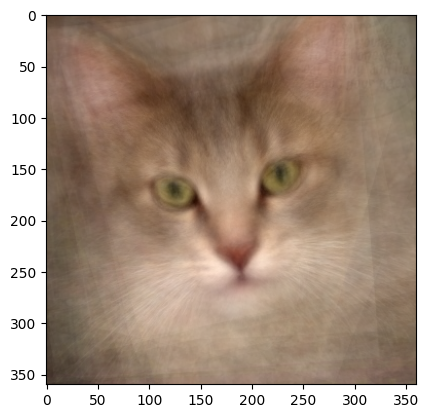

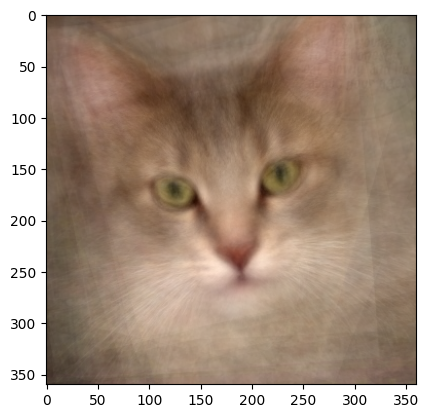

In [ ]:
from helpers import create_u_byte_image_from_vector
mean_cat_ubyte = create_u_byte_image_from_vector(mean_cat,H,W,C) #difference because he scales such that low = 0 and hi = 255, i.e. he enhances (stretches histogram)

#try normal trf
min_val, max_val =      
mean_cat_stretch = img_as_ubyte(((1/(max_val-min_val))*(mean_cat-min_val)).reshape(H,W,C))


plt.figure()
plt.imshow(mean_cat_ubyte)

plt.figure()
plt.imshow(mean_cat_stretch)

print(np.linalg.norm(mean_cat_ubyte-mean_cat_stretch))



## Find a missing cat or a cat that looks like it (using image comparison)

You have promised to take care of your neighbours cat while they are on vacation. But...Oh! no! You were in such a hurry to get to DTU that you forgot to close a window. Now the cat is gone!!! What to do? 

**Exercise 5:** *Decide that you quickly buy a new cat that looks very much like the missing cat - so nobody notices*
I decide to buy a cat :)))

Luckily, the training set is actually photos of cats that are in a *get a new cat cheap* nearby store. 

To find a cat that looks like the missing cat, you start by comparing the missing cat pixels to the pixels of the cats in the training set. The comparison between the missing cat data and the training data can be done using the sum-of-squared differences (SSD).

**Exercise 6:** *Use the `preprocess_one_cat` function to preprocess the photo of the poor missing cat*




In [7]:
#preprocess.py

**Exercise 7:** *Flatten the pixel values of the missing cat so it becomes a vector of values.*


In [29]:
missing_cat_im = io.imread("../data/MissingCatProcessed.jpg")
missing_cat = missing_cat_im.ravel()[None,:]
print(missing_cat.shape)

(1, 388800)



**Exercise 8:** *Subtract you missing cat data from all the rows in the data_matrix and for each row compute the sum of squared differences. This can for example be done by:*

In [30]:
data_matrix.shape

(100, 388800)

In [31]:
sub_data = data_matrix-missing_cat
#sanity check 
print(data_matrix[1,2],missing_cat[0,2])
print(sub_data[1,2])
sub_distances = np.linalg.norm(sub_data, axis=1)
sub_distances_check = np.sqrt(np.sum(sub_data**2,axis=1))
print(np.linalg.norm(sub_distances-sub_distances_check))

75.0 52
23.0
0.0


**Exercise 9:** *Find the cat that looks most like your missing cat by finding the cat, where the SSD is smallest. You can for example use `np.argmin`.*

In [11]:
min_idx = np.argmin(sub_distances)


**Exercise 10:** *Extract the found cat from the data_matrix and use `create_u_byte_image_from_vector` to create an image that can be visualized. Did you find a good replacement cat? Do you think your neighbour will notice? Even with their glasses on?*


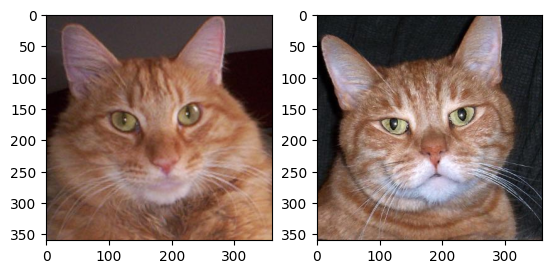

In [12]:
replacement_cat = data_matrix[min_idx,:]
fig, ax = plt.subplots(1,2)
ax[0].imshow(missing_cat_im)
ax[1].imshow(create_u_byte_image_from_vector(replacement_cat,H,W,C))

They are fairly different you know, color matches well, but shape is very different. Probably they are more related due to positioning in image; but remember, he aligns all cats to exemplar cat (catmodel)



**Exercise 11:** *You can use `np.argmax` to find the cat that looks the least like the missing cat.*

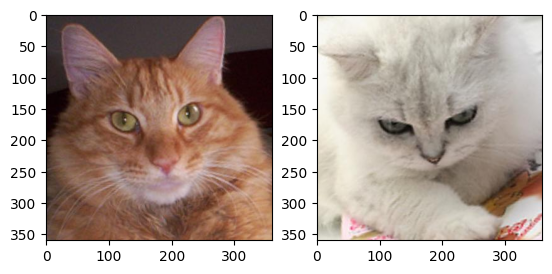

In [13]:
worst_replacement_cat = data_matrix[np.argmax(sub_distances),:]
fig, ax = plt.subplots(1,2)
ax[0].imshow(missing_cat_im)
ax[1].imshow(create_u_byte_image_from_vector(worst_replacement_cat,H,W,C))

You can also use your own photo of a cat (perhaps even your own cat). To do that you should:

- Place a jpg version of your cat photo in the folder where you had your missing cat photo. Call it for example **mycat.jpg**
- Create a landmark file called something like **mycat.jpg.cat**. It is a text file.
- In the landmark file you should create three landmarks: `3 189 98 235 101 213 142` . Here the first `3` just say there are three landmarks. The following 6 numbers are the (x, y) positions of the right eye, the left eye and the nose. You should manually update these numbers.
- Use the `preprocess_one_cat` function to preprocess the photo
- Now you can do the above routine to match your own cat.

**Optional Exercise:** *Use a photo of your own cat to find its twins*

## Principal component analysis on the cats 

We now move to more classical machine learning on cats. Namely Principal component analysis  (PCA) analysis of the cats image.

To compute the PCA, we use the [sci-kit learn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html). Note that this version of PCA automatically *centers* data. It means that it will subtract the average cat from all cats for you.

**Exercise 12:** *Start by computing the first 50 principal components:*

In [14]:
print("Computing PCA")
cats_pca = PCA(n_components=50)
cats_pca.fit(data_matrix)

Computing PCA


,n_components,50
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


This might take some time. If your compute can not handle so many images, you can manually move or delete som photos out of the **preprocessed** folder before computing the data matrix.

The amount of the total variation that each component explains can be found in `cats_pca.explained_variance_ratio_`.

**Exercise 13:** *Plot the amount of the total variation explained by each component as function of the component number.*


np.float64(0.9276036208322274)

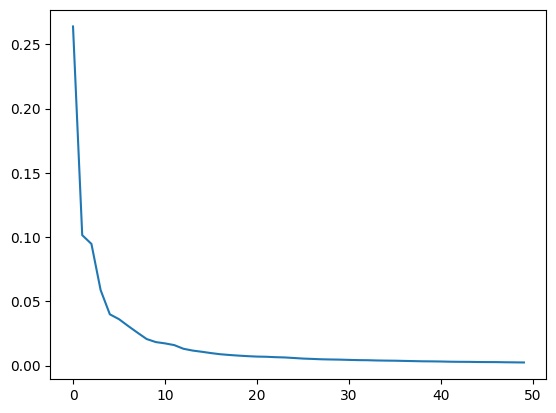

In [15]:
plt.plot(cats_pca.explained_variance_ratio_)
cats_pca.explained_variance_ratio_.sum()


**Exercise 14:** *How much of the total variation is explained by the first component?*


In [16]:
cats_pca.explained_variance_ratio_[0]

np.float64(0.2639050840444921)


We can now project all out cat images into the PCA space (that is 50 dimensional):

**Exercise 15:** *Project the cat images into PCA space*:

In [17]:
components = cats_pca.transform(data_matrix) #[N x N_p]
print(components.shape)

(100, 50)


Now each cat has a position in PCA space. For each cat this position is 50-dimensional vector. Each value in this vector describes *how much of that component* is present in that cat photo.

We can plot the first two dimensions of the PCA space, to see where the cats are placed. The first PCA coordinate for all the cats can be found using `pc_1 = components[:, 0]` .

**Exercise 16:** *Plot the PCA space by plotting all the cats first and second PCA coordinates in a (x, y) plot*


<Axes: xlabel='PC1', ylabel='PC2'>

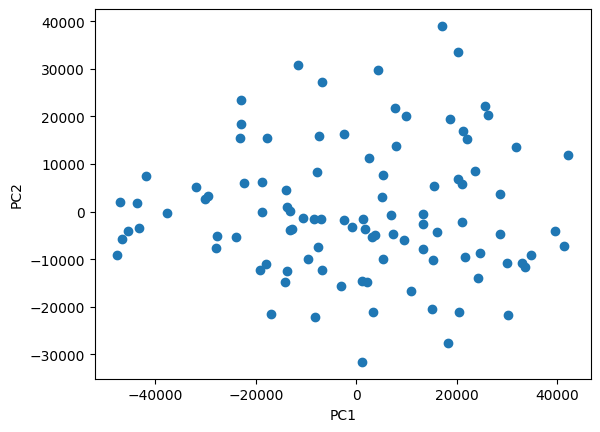

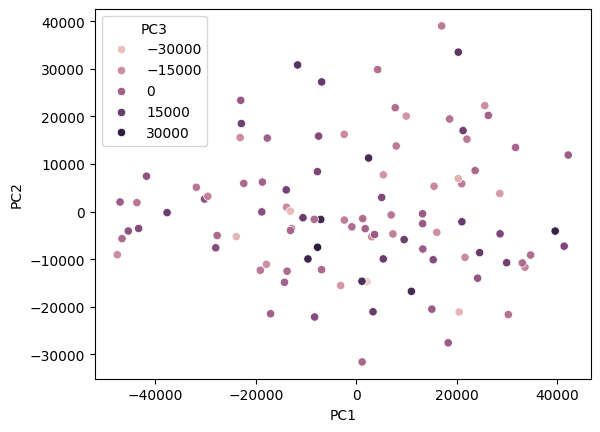

In [18]:
import pandas as pd 
import seaborn as sns 

plt.figure()
plt.scatter(components[:,0],components[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.figure()
df = pd.DataFrame(components[:,:3],columns=["PC1","PC2","PC3"])
sns.scatterplot(data=df,x="PC1",y="PC2",hue="PC3")



## Cats in space

We would like to explore what the PCA learnt about our cats in the data set. 

### Extreme cats

We start by finding out which cats that have the most *extreme coordinates* in PCA space. 

**Exercise 17:** *Use `np.argmin` and `np.argmax` to find the ids of the cats that have extreme values in the first and second PCA coordinates. Extract the cats data from the data matrix and use `create_u_byte_image_from_vector` to visualize these cats. Also plot the PCA space where you plot the extreme cats with another marker and color.*




(100, 50)


<Axes: xlabel='PC1', ylabel='PC2'>

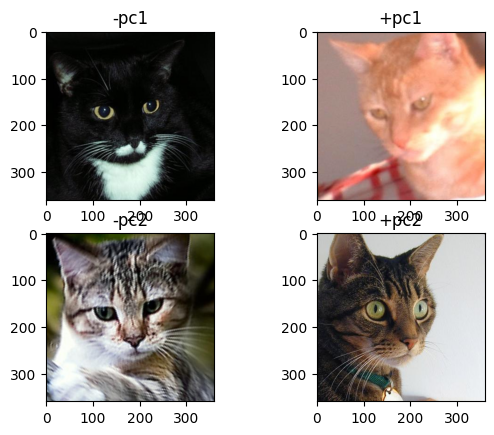

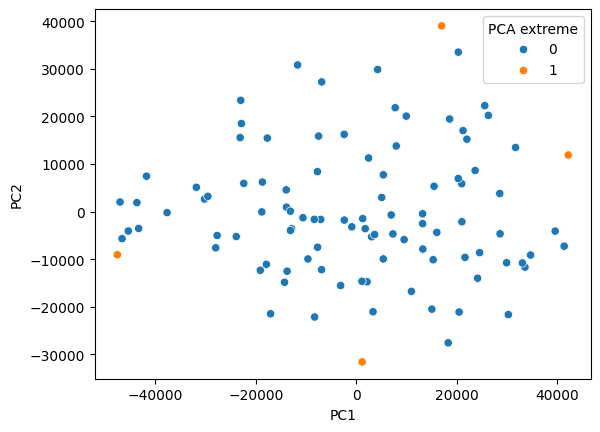

In [32]:
print(components.shape)
lo_pc0 = np.argmin(components[:,0])
hi_pc0 = np.argmax(components[:,0])
lo_pc1 = np.argmin(components[:,1])
hi_pc1 = np.argmax(components[:,1])


#gather cats 
fig, ax = plt.subplots(2,2)
ax[0,0].imshow(create_u_byte_image_from_vector(data_matrix[lo_pc0,:],H,W,C))
ax[0,0].set_title("-pc1")

ax[0,1].imshow(create_u_byte_image_from_vector(data_matrix[hi_pc0,:],H,W,C))
ax[0,1].set_title("+pc1")

ax[1,0].imshow(create_u_byte_image_from_vector(data_matrix[lo_pc1,:],H,W,C))
ax[1,1].imshow(create_u_byte_image_from_vector(data_matrix[hi_pc1,:],H,W,C))
ax[1,0].set_title("-pc2")
ax[1,1].set_title("+pc2")

pca_idx = np.array([lo_pc0,lo_pc1,hi_pc0,hi_pc1])
bool_array = np.zeros(data_matrix.shape[0]).astype(int)
bool_array[pca_idx] = 1
col = pd.DataFrame(bool_array,columns=["PCA extreme"])

plt.figure()
df_aug = pd.concat([df,col],axis=1)
sns.scatterplot(data=df_aug,x="PC1",y="PC2",hue="PCA extreme")




**Exercise 18:** *How do these extreme cat photo look like? Are some actually of such bad quality that they should be removed from the training set? If you remove images from the training set, then you should run the PCA again. Do this until you are satisfied with the quality of the training data.*


I would only consider removing the orange cat to be honest. That would possibly make sense, as the image has low quality + bad angle + saturation ie 3 things go wrong at the same time. 

### The first synthesized cat

We can use the PCA to make a so-called **generative model** that can create synthetic samples from the learnt data. It is done by adding a linear combination of principal components to the average cat image:

$$
I_\text{synth} = I_\text{average} + w_1 * P_1 + w_2 * P_2 + \ldots + w_k * P_k \enspace ,
$$

where we $P_1$ is the first principal component, $P_2$ the second and so on. Here we use $k$ principal components.

The principal components are stored in `cats_pca.components_`. So the first principal component is `cats_pca.components_[0, :]` .

**Exercise 19:** *Create your first fake cat using the average image and the first principal component. You should choose experiment with different weight values (w)* :

In [20]:
cats_pca.components_[0, :]

array([0.00101841, 0.00098791, 0.00111301, ..., 0.00152076, 0.00145316,
       0.00148981], shape=(388800,))

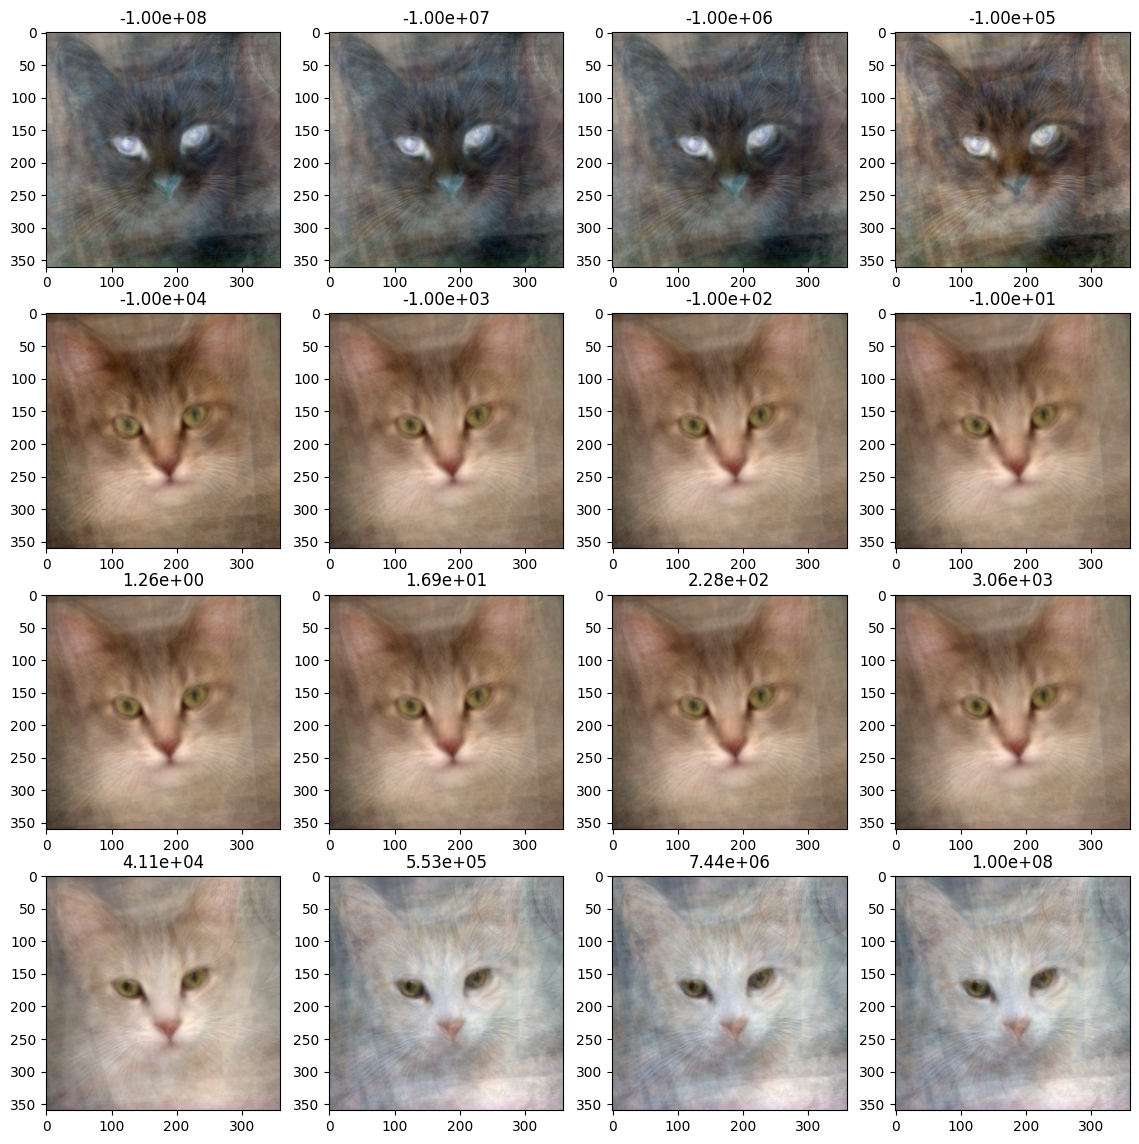

In [21]:
weights = np.logspace(1,8,num=8)

weights = np.concatenate([-weights[::-1],np.logspace(1e-1,8,num=8)])


fig, ax = plt.subplots(4,4, figsize=(14,14))

for i, ax in enumerate(ax.flatten()):  
    synth_cat = mean_cat + weights[i] * cats_pca.components_[0, :]
    ax.imshow(create_u_byte_image_from_vector(synth_cat,H,W,C))
    ax.set_title(f"{weights[i]:.2e}")

**Exercise 20:** *Use `create_u_byte_image_from_vector` visualize your fake cat.*

You can use the PCA plot we did before to select some suitable values for w.

**Exercise 21:** *Synthesize some cats, where you use both the first and second principal components and select their individual weights based on the PCA plot.*


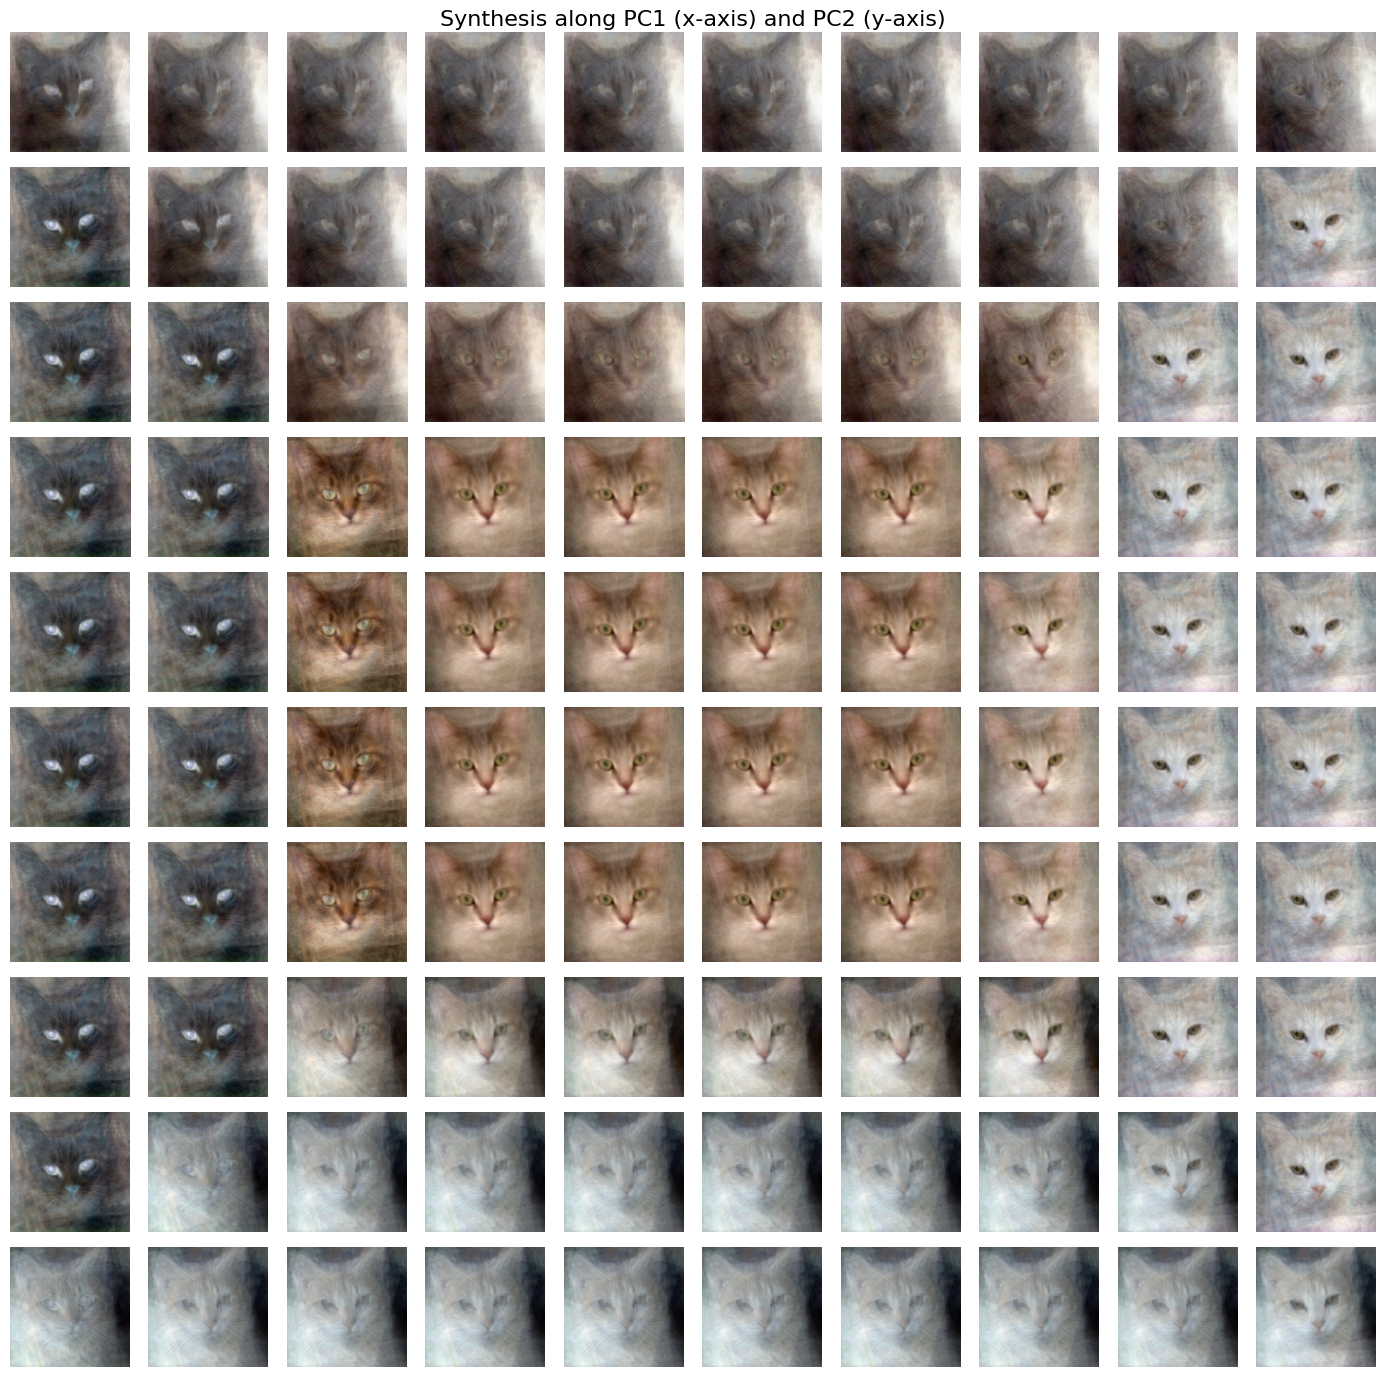

In [22]:
weights = np.logspace(1,8,num=5)
weights = np.concatenate([-weights[::-1],weights])
pc1_w, pc2_w = np.meshgrid(weights,weights) #now I want to make an image-grid where pc1 increases along x and pc2 is high in top and low in bottom.. how do I do that?
#now make an imagegrid where 
fig, ax = plt.subplots(len(weights),len(weights), figsize=(14,14))

for i in range(len(weights)):
    for j in range(len(weights)):
        # Remember: top row should be high PC2 → so invert y index
        w1 = pc1_w[i, j]
        w2 = pc2_w[::-1, :][i, j]  # flip vertically
        synth_cat = mean_cat + w1 * cats_pca.components_[0, :] + w2 * cats_pca.components_[1,:]
        ax[i, j].imshow(create_u_byte_image_from_vector(synth_cat, H, W, C))
        ax[i, j].axis("off")

# Optional labels
fig.suptitle("Synthesis along PC1 (x-axis) and PC2 (y-axis)", fontsize=16)
plt.tight_layout()
plt.show()
        




31622.776601683792 -31622.776601683792


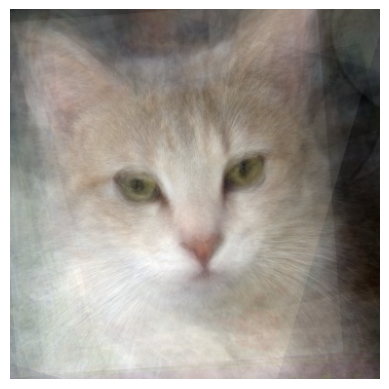

In [23]:

#extract weights from a nice cat - I like the one on the diagonal 3 steps from lower right edge 
idx = len(weights) - 1 - 2  # 2 from lower right
w1 = pc1_w[idx, idx]
w2 = pc2_w[::-1, :][idx, idx]
synth_cat = mean_cat + w1 * cats_pca.components_[0, :] + w2 * cats_pca.components_[1, :]
plt.imshow(create_u_byte_image_from_vector(synth_cat, H, W, C))
plt.axis("off")
print(w1,w2)


### The major cat variation in the data set

A very useful method to get an overview of the **major modes of variation** in a dataset is to synthesize the samples that are lying on the outer edges of the PCA space.

If we for example move a distance out of the first principal axis we can synthesize the cat image there. In this case we will try to move to $\pm \sqrt(\text{explained variance})$, where *explained variance* is the variance explained by that principal component. In code, this will look like:

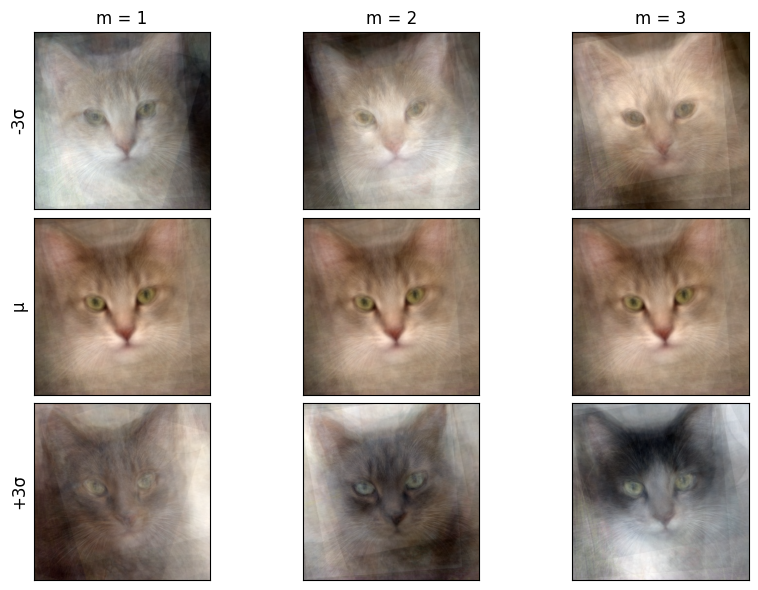

In [24]:

mode = [1,2,3]
fig, ax = plt.subplots(3,3, figsize=(9,6))

for i, m in enumerate(mode):
    synth_cat_plus = mean_cat + 3 * np.sqrt(cats_pca.explained_variance_[m]) * cats_pca.components_[m, :]
    synth_cat_minus = mean_cat - 3 * np.sqrt(cats_pca.explained_variance_[m]) * cats_pca.components_[m, :]
    ax[0,i].imshow(create_u_byte_image_from_vector(synth_cat_minus,H,W,C))
    ax[1,i].imshow(create_u_byte_image_from_vector(mean_cat,H,W,C))
    
    ax[2,i].imshow(create_u_byte_image_from_vector(synth_cat_plus,H,W,C))
    
    ax[0, i].set_xticks([])
    ax[0, i].set_yticks([])
    ax[1, i].set_xticks([])
    ax[1, i].set_yticks([])    
    ax[2, i].set_xticks([])
    ax[2, i].set_yticks([])    
    
    ax[0,i].set_title(f"m = {m}")

ax[0, 0].set_ylabel("-3σ", fontsize=12)
ax[1, 0].set_ylabel("µ", fontsize=12)
ax[2, 0].set_ylabel("+3σ", fontsize=12)
plt.tight_layout()
plt.subplots_adjust(left=0.1, wspace=0.05, hspace=0.05)

plt.show()


here **m** is the principal component that we are investigating.

**Exercise 22:** *Synthesize and visualize cats that demonstrate the first three major modes of variation. Try show the average cat in the middle of a plot, with the negative sample to the left and the positive to the right. Can you recognise some visual patterns in these modes of variation?*


pc1: 
clearly has covers color of cat but also background color. Seems quite entangled. But from earlier grid we know that pc2 had more influence on background color, so we conclude it mainly defines cat color 

pc2: Still somewhat cat color but especially background color 

pc3: could actually be the pattern on the cats face. 



### The Cat Synthesizer (EigenCats)

We are now ready to make true cat synthesizer, where cat images are synthesized based on random locations in PCA space. You can start by setting your `synth_cat = average_cat`. Then you can add all the components you want by for example (this number should be less or equal to the number of components we asked the PCA to compute):

**Exercise 23:** *Generate as many cat photos as your heart desires.*.


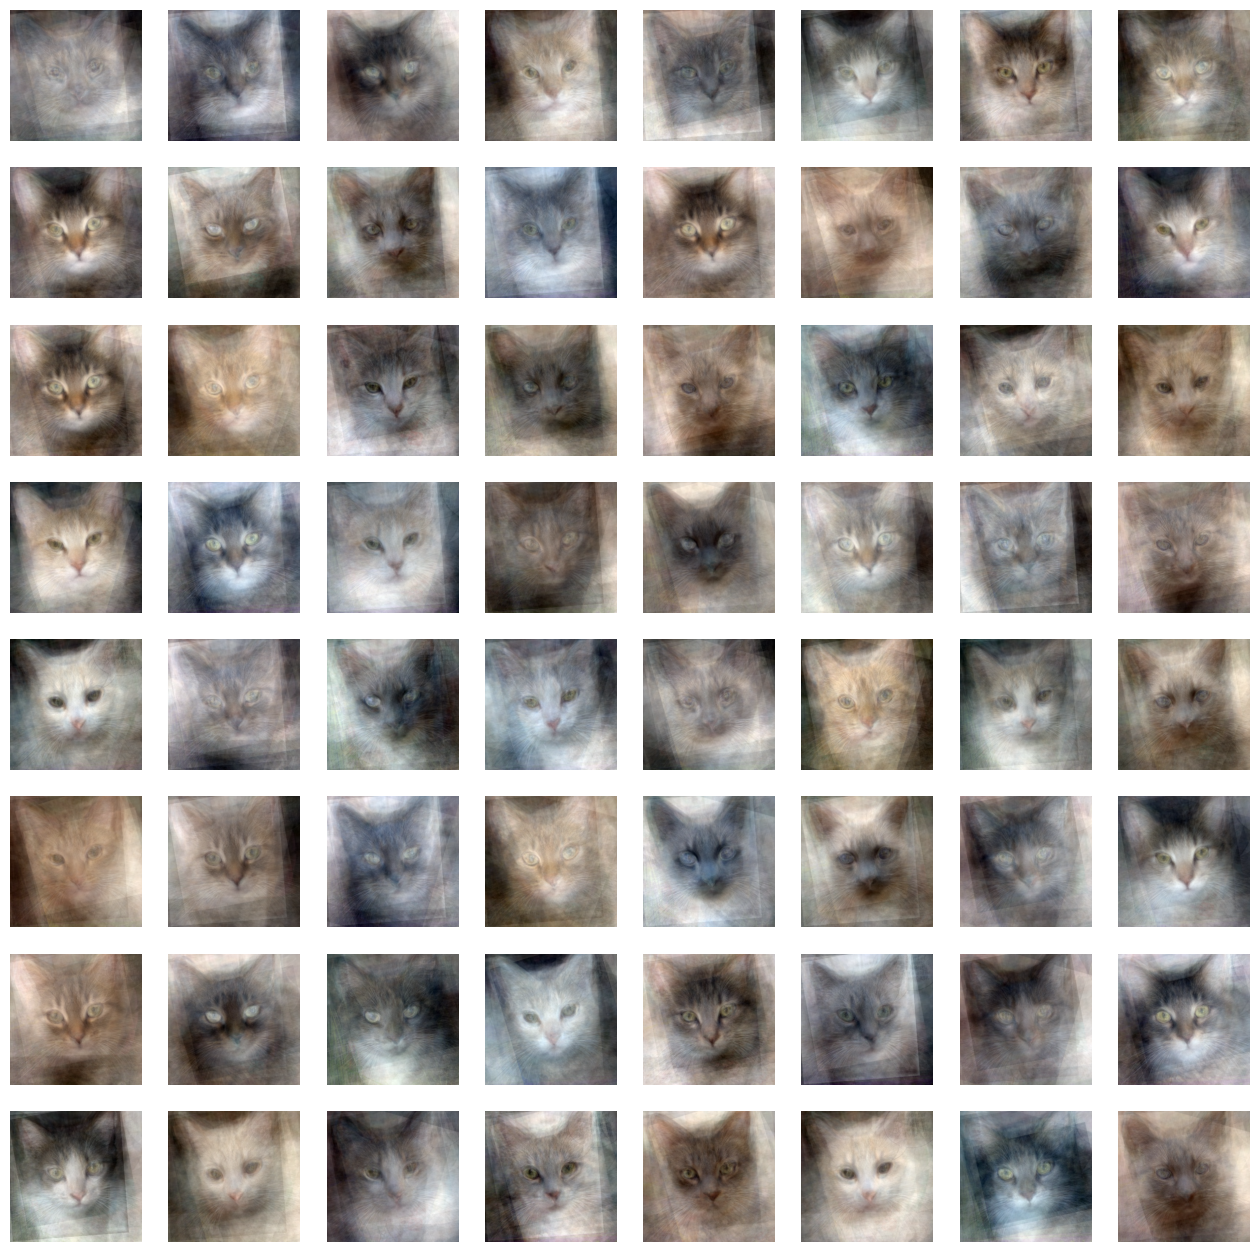

In [25]:
N_CATS = 64
n_components_to_use = 10
fig, axes = plt.subplots(8,8,figsize=(16,16))
for i, ax in enumerate(axes.flatten()):
	synth_cat = mean_cat
	for idx in range(n_components_to_use):
		w = np.random.uniform(-1, 1) * 3 * np.sqrt(cats_pca.explained_variance_[idx])
		synth_cat = synth_cat + w * cats_pca.components_[idx, :]
	
	ax.axis("off")
	ax.imshow(create_u_byte_image_from_vector(synth_cat,H,W,C))


## Cat identification in PCA space

Now back to your missing cat. We could find similar cats by computing the difference between the missing cat and all the photos in the databased. Imagine that you only needed to store the 50 weights per cats in your database to do the same type of identification?

**Exercise 24:** *Start by finding the PCA space coordinates of your missing cat:*

In [34]:
im_miss = io.imread("../data/MissingCatProcessed.jpg")
im_miss_flat = im_miss.flatten()
im_miss_flat = im_miss_flat.reshape(1, -1)
pca_coords_missing = cats_pca.transform(im_miss_flat)
print(pca_coords_missing.shape)
pca_coords = pca_coords_missing.flatten()

(1, 50)


The `flatten` calls are needed to bring the arrays into the right shapes.

**Exercise 25:** *Plot all the cats in PCA space using the first two dimensions. Plot your missing cat in the same plot, with another color and marker. Is it placed somewhere sensible and does it have close neighbours?*

In [ ]:
df = pd.DataFrame(components[:,:2],columns=["PC1","PC2"])
sns.scatterplot(data=df,x="PC1",y="PC2",hue="PC3")


ValueError: Could not interpret value `PC3` for `hue`. An entry with this name does not appear in `data`.

We can generate the synthetic cat that is the closest to your missing cat, by using the missing cats position in PCA space:

In [ ]:
n_components_to_use = 2
synth_cat = mean_cat
for idx in range(n_components_to_use):
	synth_cat = synth_cat + pca_coords[idx] * cats_pca.components_[idx, :]

**Exercise 26:** *Generate synthetic versions of your cat, where you change the n_components_to_use from 1 to for example 50.*

We can compute Euclidean distances in PCA space between your cat and all the other cats by:

In [ ]:
comp_sub = components - pca_coords
pca_distances = np.linalg.norm(comp_sub, axis=1)

**Exercise 27:** *Find the id of the cat that has the smallest and largest distance in PCA space to your missing cat. Visualize these cats. Are they as you expected? Do you think your neighours will notice a difference?*

You can also find the n closest cats by using the `np.argpartition` function. 

**Exercise 28:** *Find the ids of and visualize the 5 closest cats in PCA space. Do they look like your cat?*

What we have been doing here is what has been used for face identification and face recognition (*Matthew Turk and Alex Pentland: Eigenfaces for Recognition, 1991*)

In summary, we can now synthesize all the cat photos you will only need and we can help people that are loooking for cats that looks like another cat. On top of that, we can now use methods that are considered state-of-the-art before the step into deep learning.


## References
- [Cat data set](https://www.kaggle.com/datasets/crawford/cat-dataset)
- [sci-kit learn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)